In [200]:
import pandas as pd
import geopandas as gpd
import typing as T
from shapely.geometry import Point

In [201]:
df_listings = pd.read_csv("listings-cleaned.csv")
df_listings.head()

,project_name,floor_area,bedrooms,bathrooms,condition,parking,price_per_sqm
0,The Calinea Tower,126.0,3,3,1,0,174603.174603
1,The Calinea Tower,86.0,3,2,1,0,151453.488372
2,The Calinea Tower,30.0,1,1,1,0,200233.333333
3,The Calinea Tower,70.0,2,1,1,0,156257.142857
4,The Calinea Tower,79.0,3,2,1,0,148101.265823


In [202]:
df_properties = pd.read_csv("geocoded-properties.csv", dtype=str, encoding='utf-8-sig')
df_properties.head()

,project_name,location,full_address,cleaned_address,cleaned_query,fallback_query,lat,lon,geocode_provider,formatted_address,quality_note
0,100 West,"Pio Del Pilar, Makati, Metro Manila","100 West, Pio Del Pilar, Makati, Metro Manila,...",100 west pio del pilar makati metro manila phi...,100 west pio del pilar makati metro manila phi...,"100 West, Pio Del Pilar, Makati, Metro Manila,...",14.5584322,121.0098588,google,"100 Sen. Gil Puyat Ave. Corner Washington St.,...",FALLBACK_FULL|GEOMETRIC_CENTER
1,100 West Makati,"Pio Del Pilar, Makati, Metro Manila","100 West Makati, Pio Del Pilar, Makati, Metro ...",100 west makati pio del pilar makati metro man...,100 west makati pio del pilar makati metro man...,NaN,14.5584322,121.0098588,google,"100 Sen. Gil Puyat Ave. Corner Washington St.,...",CLEANED|GEOMETRIC_CENTER
2,1001 Parkway Residences,"Muntinlupa, Metro Manila","1001 Parkway Residences, Muntinlupa, Metro Man...",1001 parkway muntinlupa metro manila philippines,1001 parkway muntinlupa metro manila philippines,NaN,14.4141232,121.0372049,google,"C27P+JVW, Muntinlupa, Metro Manila, Philippines",CLEANED|GEOMETRIC_CENTER
3,101 Newport BLVD,"Pasay, Metro Manila","101 Newport BLVD, Pasay, Metro Manila, Philipp...",101 newport boulevard pasay metro manila phili...,101 newport boulevard pasay metro manila phili...,NaN,14.5237733,121.0129988,google,"101 Newport Blvd, Newport City, Pasay City, Me...",CLEANED|ROOFTOP
4,101 Xavierville,"Loyola Heights, Quezon City, Metro Manila","101 Xavierville, Loyola Heights, Quezon City, ...",101 xavierville loyola heights quezon city met...,101 xavierville loyola heights quezon city met...,NaN,14.6341152,121.0734137,google,"101 Xavierville Ave, Diliman, Quezon City, 110...",CLEANED|ROOFTOP


In [203]:
# join df_properties to df_listings using the project_name column
df_merged = pd.merge(
    df_listings,
    df_properties[['project_name', 'lat', 'lon']],
    how='left',
    left_on='project_name',
    right_on='project_name',
    suffixes=('', '_property')
)

# remove rows with missing lat/lon and drop project_name column
df_merged = df_merged[~df_merged['lat'].isna() & ~df_merged['lon'].isna()].copy().reset_index(drop=True)
df_merged = df_merged.drop(columns=['project_name'])
df_merged.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
floor_area,4673.0,NaN,NaN,NaN,67.171624,49.933034,12.0,33.0,52.0,80.0,309.0
bedrooms,4673.0,NaN,NaN,NaN,1.680933,0.714525,1.0,1.0,2.0,2.0,4.0
bathrooms,4673.0,NaN,NaN,NaN,1.435908,0.699966,1.0,1.0,1.0,2.0,4.0
condition,4673.0,NaN,NaN,NaN,1.773593,0.830763,1.0,1.0,2.0,3.0,3.0
parking,4673.0,NaN,NaN,NaN,0.28012,0.554466,0.0,0.0,0.0,0.0,2.0
price_per_sqm,4673.0,NaN,NaN,NaN,215246.428855,93965.810283,19157.088123,145000.0,198130.841121,280701.754386,612903.225806
lat,4673,444,14.4443435,181,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lon,4673,442,120.9992136,181,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [204]:
SOURCE_CRS = "EPSG:4326"     # WGS 84
ANALYSIS_CRS = "EPSG:32651"  # WGS 84 / UTM zone 51N

# create a GeoDataFrame from df_merged
gdf_listings = gpd.GeoDataFrame(df_merged, geometry=gpd.points_from_xy(df_merged.lon, df_merged.lat), crs=SOURCE_CRS)
gdf_listings.head()

,floor_area,bedrooms,bathrooms,condition,parking,price_per_sqm,lat,lon,geometry
0,126.0,3,3,1,0,174603.174603,14.6519513,120.9847062,POINT (120.98471 14.65195)
1,86.0,3,2,1,0,151453.488372,14.6519513,120.9847062,POINT (120.98471 14.65195)
2,30.0,1,1,1,0,200233.333333,14.6519513,120.9847062,POINT (120.98471 14.65195)
3,70.0,2,1,1,0,156257.142857,14.6519513,120.9847062,POINT (120.98471 14.65195)
4,79.0,3,2,1,0,148101.265823,14.6519513,120.9847062,POINT (120.98471 14.65195)


In [205]:
# reproject to UTM zone 51N
gdf_utm_listings = gdf_listings.to_crs(ANALYSIS_CRS)
gdf_utm_listings.head()

,floor_area,bedrooms,bathrooms,condition,parking,price_per_sqm,lat,lon,geometry
0,126.0,3,3,1,0,174603.174603,14.6519513,120.9847062,POINT (282955.103 1620796.663)
1,86.0,3,2,1,0,151453.488372,14.6519513,120.9847062,POINT (282955.103 1620796.663)
2,30.0,1,1,1,0,200233.333333,14.6519513,120.9847062,POINT (282955.103 1620796.663)
3,70.0,2,1,1,0,156257.142857,14.6519513,120.9847062,POINT (282955.103 1620796.663)
4,79.0,3,2,1,0,148101.265823,14.6519513,120.9847062,POINT (282955.103 1620796.663)


In [206]:
df_hospitals = pd.read_csv("geocoded-philhealth-hospitals.csv")

# remove rows from df_hospitals with missing lat/lon
df_hospitals = df_hospitals[~df_hospitals['lat'].isna() & ~df_hospitals['lon'].isna()].copy().reset_index(drop=True)

# create a GeoDataFrame from df_hospitals and reproject to UTM zone 51N
gdf_hospitals = gpd.GeoDataFrame(df_hospitals, geometry=gpd.points_from_xy(df_hospitals.lon, df_hospitals.lat), crs=SOURCE_CRS)
gdf_utm_hospitals = gdf_hospitals.to_crs(ANALYSIS_CRS)

In [207]:
df_stations = pd.read_csv("geocoded-train-stations.csv")

# remove rows from df_stations with missing lat/lon
df_stations = df_stations[~df_stations['lat'].isna() & ~df_stations['lon'].isna()].copy()

# create a GeoDataFrame from df_stations and reproject to UTM zone 51N
gdf_stations = gpd.GeoDataFrame(df_stations, geometry=gpd.points_from_xy(df_stations.lon, df_stations.lat), crs=SOURCE_CRS)
gdf_utm_stations = gdf_stations.to_crs(ANALYSIS_CRS)

In [208]:
df_hei = pd.read_csv("geocoded-ched-hei.csv")

# remove rows frrom df_hei with missing lat/lon
df_hei = df_hei[~df_hei['lat'].isna() & ~df_hei['lon'].isna()].copy()

# create a GeoDataFrame from df_hei and reproject to UTM zone 51N
gdf_hei = gpd.GeoDataFrame(df_hei, geometry=gpd.points_from_xy(df_hei.lon, df_hei.lat), crs=SOURCE_CRS)
gdf_utm_hei = gdf_hei.to_crs(ANALYSIS_CRS)

In [209]:
# Add columns for the distance of nearest hospital, HEI, and station to gdf_utm_listings

def get_nearest(row, gdf_targets):
    distances = gdf_targets.distance(row['geometry'])
    min_idx = distances.idxmin()
    return min_idx

# distance to nearest hospital in meters
gdf_utm_listings['dist_station'] = gdf_utm_listings['geometry'].apply(
    lambda geom: gdf_utm_stations.distance(geom).min()
)

# distance to nearest hei in meters
gdf_utm_listings['dist_hei'] = gdf_utm_listings['geometry'].apply(
    lambda geom: gdf_utm_hei.distance(geom).min()
)

# distance to nearest station in meters
gdf_utm_listings['dist_hospital'] = gdf_utm_listings['geometry'].apply(
    lambda geom: gdf_utm_hospitals.distance(geom).min()
)

gdf_utm_listings.head()

,floor_area,bedrooms,bathrooms,condition,parking,price_per_sqm,lat,lon,geometry,dist_station,dist_hei,dist_hospital
0,126.0,3,3,1,0,174603.174603,14.6519513,120.9847062,POINT (282955.103 1620796.663),281.292648,198.139354,673.321613
1,86.0,3,2,1,0,151453.488372,14.6519513,120.9847062,POINT (282955.103 1620796.663),281.292648,198.139354,673.321613
2,30.0,1,1,1,0,200233.333333,14.6519513,120.9847062,POINT (282955.103 1620796.663),281.292648,198.139354,673.321613
3,70.0,2,1,1,0,156257.142857,14.6519513,120.9847062,POINT (282955.103 1620796.663),281.292648,198.139354,673.321613
4,79.0,3,2,1,0,148101.265823,14.6519513,120.9847062,POINT (282955.103 1620796.663),281.292648,198.139354,673.321613


In [210]:
# count of hospitals within 500m
gdf_utm_listings['hospitals_within_500m'] = gdf_utm_listings['geometry'].apply(
    lambda geom: gdf_utm_hospitals[gdf_utm_hospitals.distance(geom) <= 500].shape[0]
)

# count of HEIs within 500m
gdf_utm_listings['hei_within_500m'] = gdf_utm_listings['geometry'].apply(
    lambda geom: gdf_utm_hei[gdf_utm_hei.distance(geom) <= 500].shape[0]
)

# count of stations within 500m
gdf_utm_listings['stations_within_500m'] = gdf_utm_listings['geometry'].apply(
    lambda geom: gdf_utm_stations[gdf_utm_stations.distance(geom) <= 500].shape[0]
)

# total count of hospitals, HEIs, and stations within 500m
gdf_utm_listings['amenities_within_500m'] = gdf_utm_listings[['hospitals_within_500m', 'hei_within_500m', 'stations_within_500m']].sum(axis=1)

# drop intermediate columns
gdf_utm_listings = gdf_utm_listings.drop(columns=['hospitals_within_500m', 'hei_within_500m', 'stations_within_500m'])

gdf_utm_listings

,floor_area,bedrooms,bathrooms,condition,parking,price_per_sqm,lat,lon,geometry,dist_station,dist_hei,dist_hospital,amenities_within_500m
0,126.0,3,3,1,0,174603.174603,14.6519513,120.9847062,POINT (282955.103 1620796.663),281.292648,198.139354,673.321613,3
1,86.0,3,2,1,0,151453.488372,14.6519513,120.9847062,POINT (282955.103 1620796.663),281.292648,198.139354,673.321613,3
2,30.0,1,1,1,0,200233.333333,14.6519513,120.9847062,POINT (282955.103 1620796.663),281.292648,198.139354,673.321613,3
3,70.0,2,1,1,0,156257.142857,14.6519513,120.9847062,POINT (282955.103 1620796.663),281.292648,198.139354,673.321613,3
4,79.0,3,2,1,0,148101.265823,14.6519513,120.9847062,POINT (282955.103 1620796.663),281.292648,198.139354,673.321613,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4668,33.0,2,1,1,0,122786.696970,14.6887511,120.9791041,POINT (282387.936 1624874.37),3839.979921,170.767299,161.399851,3
4669,33.0,2,1,1,0,135869.787879,14.6887511,120.9791041,POINT (282387.936 1624874.37),3839.979921,170.767299,161.399851,3
4670,33.0,2,1,2,0,151487.878788,14.6887511,120.9791041,POINT (282387.936 1624874.37),3839.979921,170.767299,161.399851,3
4671,33.0,2,1,1,0,122786.696970,14.6887511,120.9791041,POINT (282387.936 1624874.37),3839.979921,170.767299,161.399851,3


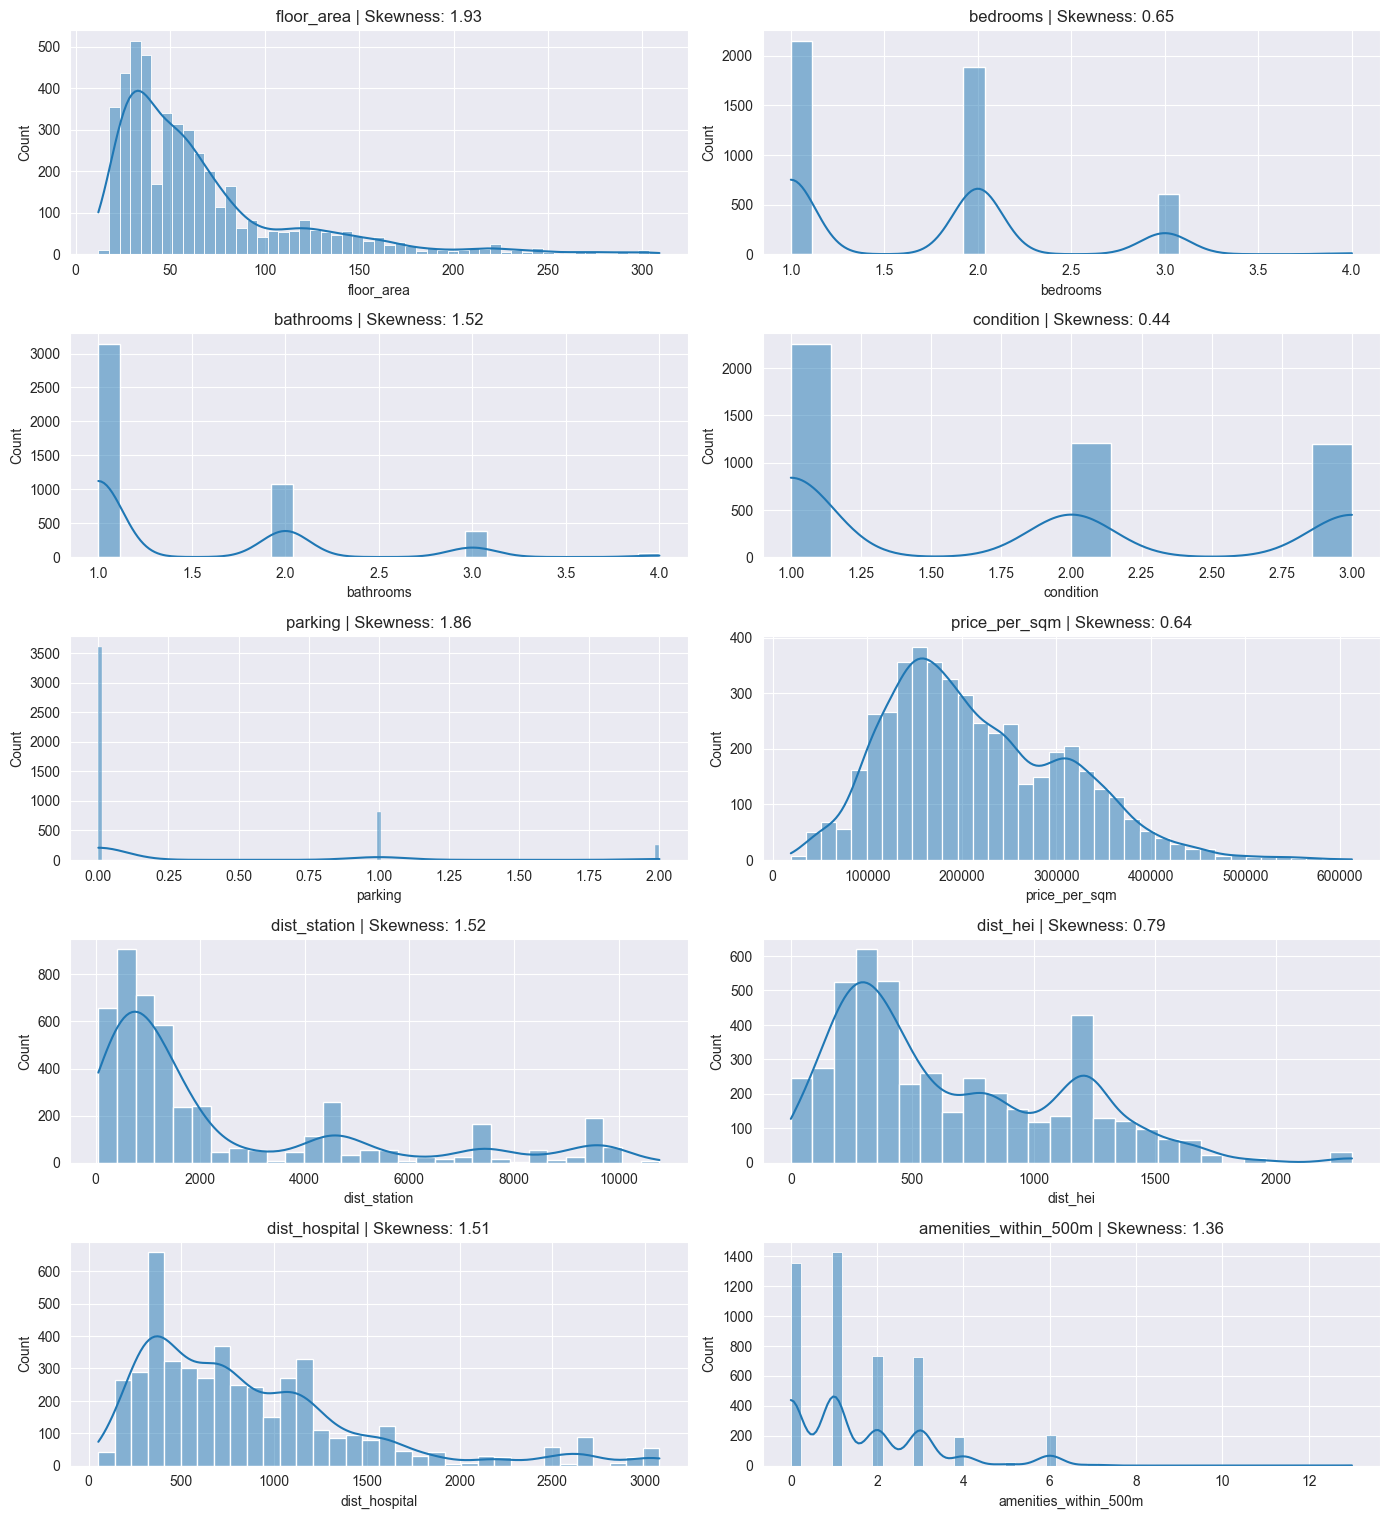

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("darkgrid")

numerical_columns = gdf_utm_listings.select_dtypes(include=["int64", "float64"]).columns

plt.figure(figsize=(14, len(numerical_columns) * 3))
for idx, feature in enumerate(numerical_columns, 1):
    plt.subplot(len(numerical_columns), 2, idx)
    sns.histplot(gdf_utm_listings[feature], kde=True)
    plt.title(f"{feature} | Skewness: {round(gdf_utm_listings[feature].skew(), 2)}")

plt.tight_layout()
plt.show()

In [249]:
# feature groups
price_features = ['price_per_sqm']
property_features = ['floor_area', 'bedrooms', 'bathrooms', 'parking', 'condition']
access_features = ['dist_station', 'dist_hei', 'dist_hospital', 'amenities_within_500m']

# drop geometry, lat, lon columns
df_features = gdf_utm_listings.drop(columns=['geometry', 'lat', 'lon']).copy()
df_features

,floor_area,bedrooms,bathrooms,condition,parking,price_per_sqm,dist_station,dist_hei,dist_hospital,amenities_within_500m
0,126.0,3,3,1,0,174603.174603,281.292648,198.139354,673.321613,3
1,86.0,3,2,1,0,151453.488372,281.292648,198.139354,673.321613,3
2,30.0,1,1,1,0,200233.333333,281.292648,198.139354,673.321613,3
3,70.0,2,1,1,0,156257.142857,281.292648,198.139354,673.321613,3
4,79.0,3,2,1,0,148101.265823,281.292648,198.139354,673.321613,3
...,...,...,...,...,...,...,...,...,...,...
4668,33.0,2,1,1,0,122786.696970,3839.979921,170.767299,161.399851,3
4669,33.0,2,1,1,0,135869.787879,3839.979921,170.767299,161.399851,3
4670,33.0,2,1,2,0,151487.878788,3839.979921,170.767299,161.399851,3
4671,33.0,2,1,1,0,122786.696970,3839.979921,170.767299,161.399851,3


In [250]:
import numpy as np

# identify numeric columns
num_cols = df_features.select_dtypes(include=[np.number]).columns

# compute skewness for numeric columns
skew_vals = df_features[num_cols].skew().sort_values(ascending=False)
print(skew_vals)

floor_area               1.929788
parking                  1.860759
dist_station             1.523426
bathrooms                1.521306
dist_hospital            1.511945
amenities_within_500m    1.363386
dist_hei                 0.789877
bedrooms                 0.645673
price_per_sqm            0.644341
condition                0.443064
dtype: float64


In [253]:
# choose columns with right skew >= 1 for log transformation
log1p_cols = skew_vals[skew_vals >= 1].index.tolist()

# apply log1p transformation
df_features[log1p_cols] = df_features[log1p_cols].apply(np.log1p)

# stanardize numerical features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_features_scaled = scaler.fit_transform(df_features[num_cols])
df_features_scaled = pd.DataFrame(df_features_scaled, columns=num_cols)
df_features_scaled

,floor_area,bedrooms,bathrooms,condition,parking,price_per_sqm,dist_station,dist_hei,dist_hospital,amenities_within_500m
0,1.326501,1.846273,2.060968,-0.931283,-0.533829,-0.432579,-1.349556,-0.974120,0.021663,1.005648
1,0.772137,1.846273,1.040609,-0.931283,-0.533829,-0.678968,-1.349556,-0.974120,0.021663,1.005648
2,-0.961202,-0.953089,-0.664581,-0.931283,-0.533829,-0.159789,-1.349556,-0.974120,0.021663,1.005648
3,0.458244,0.446592,-0.664581,-0.931283,-0.533829,-0.627841,-1.349556,-0.974120,0.021663,1.005648
4,0.644017,1.846273,1.040609,-0.931283,-0.533829,-0.714647,-1.349556,-0.974120,0.021663,1.005648
...,...,...,...,...,...,...,...,...,...,...
4668,-0.790388,0.446592,-0.664581,-0.931283,-0.533829,-0.984077,0.949178,-1.032479,-2.156228,1.005648
4669,-0.790388,0.446592,-0.664581,-0.931283,-0.533829,-0.844830,0.949178,-1.032479,-2.156228,1.005648
4670,-0.790388,0.446592,-0.664581,0.272558,-0.533829,-0.678602,0.949178,-1.032479,-2.156228,1.005648
4671,-0.790388,0.446592,-0.664581,-0.931283,-0.533829,-0.984077,0.949178,-1.032479,-2.156228,1.005648
